# Kliinisen tutkimuksen tutkimuskeskuskoordinaattien projisointi kartoitusta varten PROC GPROJECTilla

## Tiivistelmä

Kliinisen tutkimuksen operaatiotiimi tarvitsee tasokartan monikeskustutkimuksen (vaihe III) maantieteellisestä jalanjäljestä. Tässä muistikirjassa generoidaan synteettisiä leveys-/pituusastekoordinaatteja tutkimuskeskuksille, jotka klusteroituvat viiden yhdysvaltalaisen aluekeskuksen ympärille, ja käytetään sitten **PROC GPROJECTia** pallomaisten koordinaattien muuntamiseen karteesisiksi X/Y-arvoiksi kolmella projektiomenetelmällä (Albersin pinta-alansäilyttävä, Lambertin konforminen mukautetuilla standardirinnakkaisilla ja aluerajauksella, sekä mannerten Yhdysvaltoihin keskitetty gnomoninen), havainnollistaen miten projektion valinta ja rajaus vaikuttavat tutkimuskeskuskarttaan.

## Tietolähteet

| Aineisto | Rivit | Keskeiset muuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 aluekeskusta x 12 tutkimuskeskusta) | `site_id` ($8 tunnus), `region` ($12), `x` (pituusaste, astetta, itä-positiivinen), `y` (leveysaste, astetta), `enroll` (ilmoittautuneet), `segment` (karttasegmentin tunnus) | Synteettisiä vaiheen III kliinisen tutkimuksen tutkimuskeskusten sijainteja hajautettuna viiden yhdysvaltalaisen aluekeskuksen (Länsi, Keskilänsi, Koillinen, Etelä, Kaakko) ympärille käyttäen `rand('normal')`-satunnaisvaihtelua ja `rand('poisson')`-ilmoittautumislukumääriä |

# Kliinisen tutkimuksen tutkimuskeskuskoordinaattien projisointi PROC GPROJECTilla

Kun toimeksiantaja ajaa maantieteellisesti hajautettua vaiheen III tutkimusta, kliinisen operaation ryhmä haluaa usein yhden kartan, joka näyttää jokaisen tutkimuskeskuksen kokonsa tai värinsä ilmoittautumisen mukaan mitoitettuna. Tutkimuskeskusten sijainnit saapuvat **pituus-/leveysastepareina**, mutta tasokartta tarvitsee **tasomaiset X/Y-koordinaatit**. `PROC GPROJECT` suorittaa tämän pallomaisesta karteesiseksi -muunnoksen soveltamalla karttaprojektiota, jotta etäisyydet ja pinta-alat renderöityvät järkevästi.

Tässä muistikirjassa:

1. Generoimme synteettiset tutkimuskeskuskoordinaatit klusteroituna viiden yhdysvaltalaisen aluekeskuksen ympärille.
2. Sovellamme oletusarvoista **Albersin pinta-alansäilyttävää** projektiota.
3. Sovellamme **Lambertin konformista** projektiota mukautetuilla standardirinnakkaisilla ja rajaamme Yhdysvaltain manneralueeseen.
4. Sovellamme **gnomonista** projektiota keskitettynä maan maantieteelliseen keskikohtaan, säilyttäen alkuperäiset koordinaatit `ASIS`-optiolla.

Kaikki on itsenäistä: ei ulkoisia tiedostoja, ei verkkoyhteyttä.

## Vaihe 1 — Synteettisten tutkimuskeskuskoordinaattien generointi

Siemennämme satunnaislukugeneraattorin `call streaminit`-kutsulla toistettavuuden vuoksi ja sijoitamme sitten 12 tutkimuskeskusta jokaisen viiden aluekeskuskaupungin ympärille. Pituusasteet tallennetaan itä-positiivisina asteina (negatiivisina läntisellä pallonpuoliskolla) ja leveysasteet asteina. Jokainen rivi kantaa myös ilmoittautumislukumäärän ja `segment`-muuttujan (GPROJECT säilyttää ei-koordinaattisarakkeet projektion läpi).

In [1]:
TIEDOT trial_sites;
    CALL streaminit(20260531);
    PITUUS site_id $8 region $12;
    /* Viisi yhdysvaltalaista aluekeskusta: pituusaste (itä+), leveysaste */
    TAULUKKO clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    TAULUKKO clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    TEE hub = 1 ASTI 5;
        JOS hub = 1 NIIN region = 'Länsi';
        MUUTEN JOS hub = 2 NIIN region = 'Keskilänsi';
        MUUTEN JOS hub = 3 NIIN region = 'Koillinen';
        MUUTEN JOS hub = 4 NIIN region = 'Etelä';
        MUUTEN region = 'Kaakko';
        TEE s = 1 ASTI 12;
            site_id = cats('S', KIRJOITA(hub, z1.), KIRJOITA(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* pituusaste, astetta */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* leveysaste, astetta */
            enroll  = round(rand('poisson', 60));           /* ilmoittautuneet     */
            segment = 1;
            TULOSTE;
        LOPPU;
    LOPPU;
    POISTA hub s;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=trial_sites(obs=10) NIMIKE;
    NIMIKE site_id="Kohteen tunnus" region="Alue" x="Pituusaste" y="Leveysaste"
          enroll="Ilmoittautuneet" segment="Segmentti";
    OTSIKKO "Näyte synteettisistä kliinisen tutkimuksen tutkimuskeskuksista (projisoimattomat pituus-/leveysasteet)";
SUORITA;

         Näyte synteettisistä kliinisen tutkimuksen tutkimuskeskuksista (projisoimattomat pituus-/leveysasteet)         

  Obs  Kohteen tunnus    Alue       Pituusaste     Leveysaste  Ilmoittautuneet  Segmentti
    1  S101            Länsi   -121.6437232216  37.7677668495               65          1
    2  S102            Länsi   -120.7384024716  37.5083287903               61          1
    3  S103            Länsi   -121.5133780284  37.8633933883               72          1
    4  S104            Länsi   -121.2086817368  38.7723343392               68          1
    5  S105            Länsi   -121.0499572297   37.175813806               54          1
    6  S106            Länsi   -124.0531899967   35.778231667               72          1
    7  S107            Länsi   -120.9370181032  39.0576714397               64          1
    8  S108            Länsi   -126.8495029747  36.6474680375               55          1
    9  S109            Länsi    -123.475989897  37.1427965254       


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Vaihe 2 — Oletusarvoinen Albersin pinta-alansäilyttävä projektio

**Albersin** pinta-alansäilyttävä kartioprojektio on GPROJECTin oletusarvo ja järkevä valinta maan mittakaavan kartalle, jossa *suhteellisen pinta-alan* säilyttäminen on tärkeää (esim. alueellisten kohdealueiden koon vertailu).

Koska koordinaattimme on tallennettu **asteina** ja **itä-positiivisena pituusasteena**, määritämme `DEGREE`- ja `EASTLONG`-optiot. `ID`-lause nimeää muuttujan, joka yksilöi jokaisen yksikön; projisoidut tasokoordinaatit kirjoitetaan takaisin `x`- ja `y`-muuttujiin `OUT=`-aineistossa.

In [2]:
PROSEDUURI GPROJECT TIEDOT=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=sites_albers(obs=10) NIMIKE;
    NIMIKE site_id="Kohteen tunnus" region="Alue" x="X (Albers)" y="Y (Albers)"
          enroll="Ilmoittautuneet" segment="Segmentti";
    OTSIKKO "Tutkimuskeskukset Albersin pinta-alansäilyttävän projektion jälkeen (tasokoordinaatit X/Y)";
SUORITA;

         Näyte synteettisistä kliinisen tutkimuksen tutkimuskeskuksista (projisoimattomat pituus-/leveysasteet)         

               Tutkimuskeskukset Albersin pinta-alansäilyttävän projektion jälkeen (tasokoordinaatit X/Y)               

  Obs  Kohteen tunnus    Alue     X (Albers)    Y (Albers)  Ilmoittautuneet  Segmentti
    1  S101            Länsi    -0.346124731  0.0516986079               65          1
    2  S102            Länsi   -0.3353644139  0.0440400181               61          1
    3  S103            Länsi   -0.3439609675  0.0528501365               72          1
    4  S104            Länsi   -0.3357513354   0.067213083               68          1
    5  S105            Länsi   -0.3410170723  0.0394882801               54          1
    6  S106            Länsi   -0.3879364507  0.0273340733               72          1
    7  S107            Länsi   -0.3309127579  0.0711146305               64          1
    8  S108            Länsi   -0.4204191205  0.0538118922  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Vaihe 3 — Lambertin konforminen projektio mukautetuilla rinnakkaisilla ja rajauksella

**Lambertin konforminen** kartioprojektio säilyttää *muodon ja paikalliset kulmat*, mikä on suositeltavaa, kun karttaa käytetään navigointiin tai suunnattujen ominaisuuksien päällekkäisasetteluun. Yhdysvaltain manneralueelle standardirinnakkaiset noin 33 astetta pohjoista ja 45 astetta pohjoista ovat tavanomaisia, joten asetamme ne eksplisiittisesti `PARALLEL1=`- ja `PARALLEL2=`-optioilla.

Rajaamme myös kartan Yhdysvaltain manneralueen ikkunaan käyttäen rajausoptioita `LATMIN=`, `LATMAX=`, `LONGMIN=` ja `LONGMAX=`. Kaikki tutkimuskeskukset, jotka jäävät tämän leveys-/pituusastelaatikon ulkopuolelle, pudotetaan ennen projisointia, joten tulostuksen havaintomäärä voi olla pienempi kuin syötteen.

In [3]:
PROSEDUURI GPROJECT TIEDOT=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=sites_lambert(obs=10) NIMIKE;
    NIMIKE site_id="Kohteen tunnus" region="Alue" x="X (Lambert)" y="Y (Lambert)"
          enroll="Ilmoittautuneet" segment="Segmentti";
    OTSIKKO "Tutkimuskeskukset Lambertin konformisen projektion jälkeen (rajattu Yhdysvaltain manneralueeseen)";
SUORITA;

               Tutkimuskeskukset Albersin pinta-alansäilyttävän projektion jälkeen (tasokoordinaatit X/Y)               

           Tutkimuskeskukset Lambertin konformisen projektion jälkeen (rajattu Yhdysvaltain manneralueeseen)            

  Obs  Kohteen tunnus    Alue    X (Lambert)   Y (Lambert)  Ilmoittautuneet  Segmentti
    1  S101            Länsi   -0.3473024124  0.0279382533               65          1
    2  S102            Länsi   -0.3365626234  0.0201991247               61          1
    3  S103            Länsi   -0.3451238364  0.0290365995               72          1
    4  S104            Länsi   -0.3367881094  0.0430616123               68          1
    5  S105            Länsi   -0.3422656751  0.0158037156               54          1
    6  S106            Länsi   -0.3894389642  0.0046370991               72          1
    7  S107            Länsi   -0.3319086764  0.0468276119               64          1
    8  S109            Länsi   -0.3746144745  0.0248234546  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Vaihe 4 — Gnomoninen projektio keskitettynä maahan, alkuperäiset säilyttäen

**Gnomoninen** atsimutaalinen projektio renderöi jokaisen isoympyrän suorana viivana, mikä on hyödyllistä, kun halutaan päätellä lyhin reitti tutkimuskeskusten välillä (esimerkiksi monitoroijan käyntimatkan suunnittelussa). Vääristymä kasvaa etäisyyden mukana projektion navasta, joten keskitämme navan Yhdysvaltain manneralueen maantieteelliseen keskikohtaan optioilla `POLELAT=39` ja `POLELONG=-98`.

`ASIS`-optio käskee GPROJECTia säilyttämään alkuperäiset projisoimattomat koordinaatit projisoitujen arvojen rinnalla, joten tulostusaineisto kantaa sekä tasomaiset `X`/`Y`- että lähde-`LONG`/`LAT`-arvot — kätevää ilmoittautumismittareiden yhdistämiseksi takaisin kumpaan tahansa koordinaattiavaruuteen.

`PARMENTRY`-lause on esitetty vaihtoehtoisena tapana antaa projektioparametrit avain=arvo-ohituksina.

In [4]:
PROSEDUURI GPROJECT TIEDOT=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=sites_gnomon(obs=10) NIMIKE;
    NIMIKE site_id="Kohteen tunnus" region="Alue" x="X (gnomoninen)" y="Y (gnomoninen)"
          enroll="Ilmoittautuneet" segment="Segmentti"
          long="Pituusaste (alkup.)" lat="Leveysaste (alkup.)";
    OTSIKKO "Tutkimuskeskukset gnomonisen projektion jälkeen (ASIS säilyttää alkuperäisen pituus-/leveysasteen)";
SUORITA;

           Tutkimuskeskukset Lambertin konformisen projektion jälkeen (rajattu Yhdysvaltain manneralueeseen)            

           Tutkimuskeskukset gnomonisen projektion jälkeen (ASIS säilyttää alkuperäisen pituus-/leveysasteen)           

  Obs  Kohteen tunnus    Alue  X (gnomoninen)  Y (gnomoninen)  Ilmoittautuneet  Segmentti  Pituusaste (alkup.)  Leveysaste (alkup.)
    1  S101            Länsi    -0.3343477981    0.0213614461               65          1      -121.6437232216        37.7677668495
    2  S102            Länsi    -0.3221611694    0.0134152735               61          1      -120.7384024716        37.5083287903
    3  S103            Länsi    -0.3319480803    0.0225717184               72          1      -121.5133780284        37.8633933883
    4  S104            Länsi    -0.3230855797    0.0375741352               68          1      -121.2086817368        38.7723343392
    5  S105            Länsi    -0.3283677206    0.0086308769               54          1      -


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Vaihe 5 — Projisoidun tutkimuskeskuskartan renderöinti

Projisoinnin koko tarkoitus on piirtää kartta. Syötämme Albersin `OUT=`-aineiston suoraan **PROC SGPLOTiin**, piirtäen tasomaiset `X`/`Y`-koordinaatit ja väritettynä jokainen merkki `region`-muuttujan mukaan. Koska projektio säilytti suhteellisen maantieteen, viisi aluekeskusklusteria asettuvat kaavion odotettuihin kulmiin — Länsi vasemmalla, Koillinen oikealla ylhäällä, Etelä ja Kaakko alareunassa — antaen kliinisen operaation ryhmälle tiivistelmässä kuvatun pinta-alauskollisen jalanjäljen.

           Tutkimuskeskukset gnomonisen projektion jälkeen (ASIS säilyttää alkuperäisen pituus-/leveysasteen)           




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


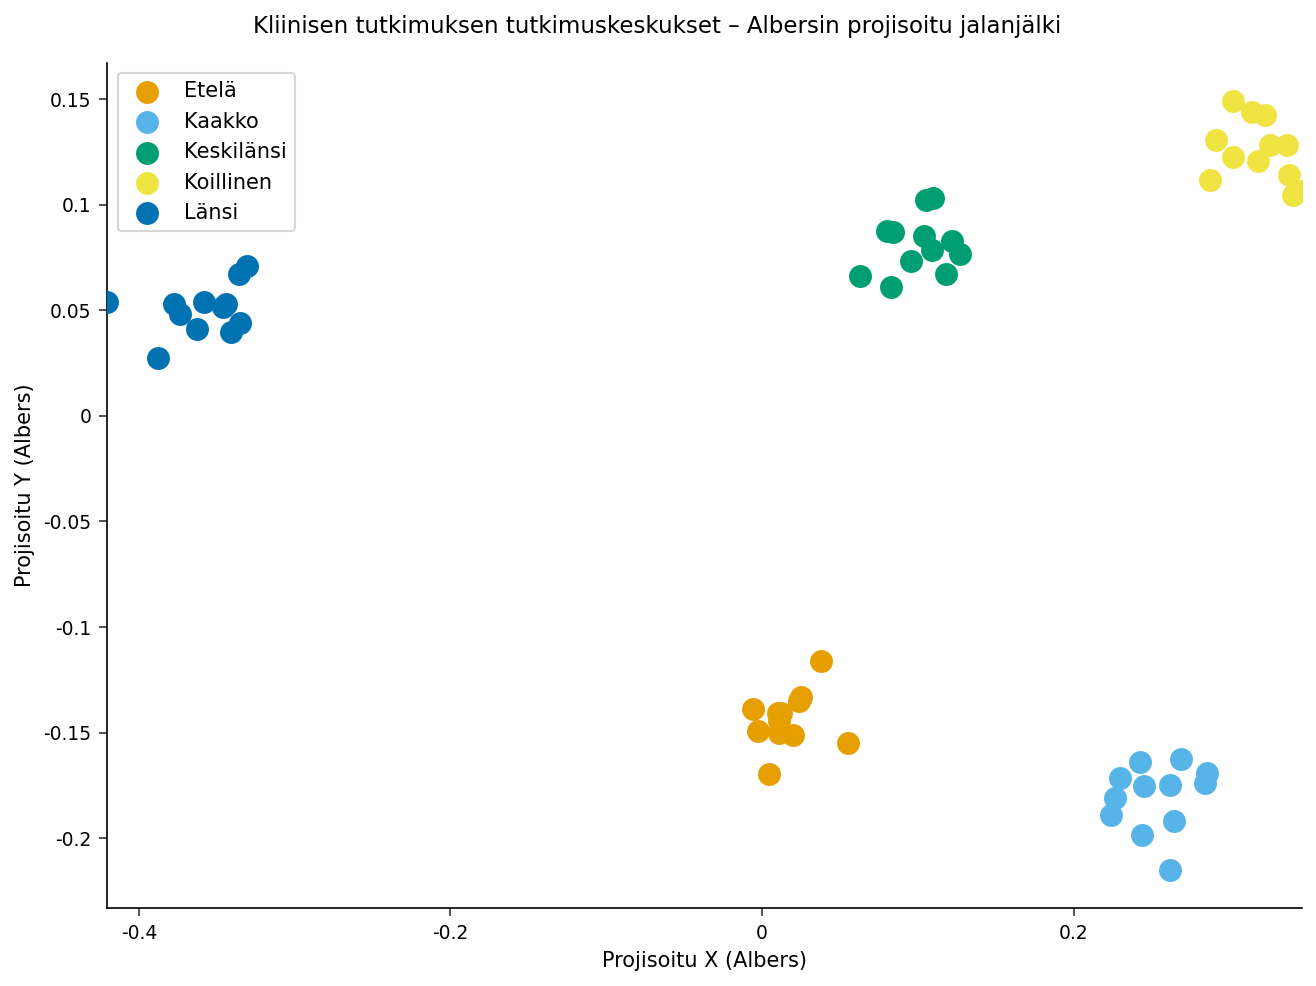

In [5]:
PROSEDUURI SGPLOT TIEDOT=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS NIMIKE="Projisoitu X (Albers)";
    YAXIS NIMIKE="Projisoitu Y (Albers)";
    OTSIKKO "Kliinisen tutkimuksen tutkimuskeskukset – Albersin projisoitu jalanjälki";
SUORITA;

## Tulosten tulkinta

- **Albers (vaihe 2)** muunsi kaikki 60 tutkimuskeskusta tasokoordinaateiksi säilyttäen suhteellisen pinta-alan — Länsi-, Keskilänsi-, Koillinen-, Etelä- ja Kaakkoklusterit säilyttävät suhteellisen maantieteellisen jalanjälkensä, mikä on oikea perusta pinta-alauskolliselle ilmoittautumisen lämpökartalle.
- **Lambert rajauksella (vaihe 3)** säilytti paikallisen muodon ja pudotti `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`-ikkunaa soveltamalla ne synteettiset tutkimuskeskukset, jotka hajaantuivat Yhdysvaltain manneralueen ulkopuolelle — tässä määrä laski 60:stä 58:aan, joten kaksi karttaa muuten venyttänyttä poikkeavaa koordinaattia poistettiin ennen projisointia.
- **Gnomoninen `ASIS`illä (vaihe 4)** keskitti projektion maan sisäosaan ja tuotti `ASIS`in ansiosta aineiston, joka kantaa sekä projisoidut `X`/`Y`- että alkuperäiset `LONG`/`LAT`-arvot. Isoympyrät näkyvät suorina viivoina, joten suorien viivojen etäisyydet tällä kartalla ovat likimäärin todellisia lyhimpiä reittejä tutkimuskeskusten välillä.
- **Renderöity jalanjälki (vaihe 5)** vahvistaa projektion toimineen: Albersin `X`/`Y`-koordinaattien piirtäminen alueen mukaan asettaa viisi aluekeskusklusteria tasokuvan odotettuihin kulmiin — juuri sen pinta-alauskollisen tutkimuskeskuskartan, jonka tiivistelmä lupasi.

**Johtopäätös kliinisen operaation ryhmälle:** projektio ei ole kosmeettinen. Valitse **Albers** pinta-alauskolliselle ilmoittautumistiheydelle, **Lambert** muotouskolliselle päällekkäisasettelulle aluerajauksella ja **gnomoninen**, kun tutkimuskeskusten välinen matkaetäisyys ohjaa analyysia. Kuten vaihe 5 osoittaa, projisoitu `OUT=`-aineisto syötetään suoraan PROC SGPLOTiin (tai PROC GMAPiin) lopullisen tutkimuskeskuskartan renderöimiseksi.